# 📊 Malaysia Economic Analytics: Analysis of Annual Real GDP and GNI

## 1.0 Introduction

This project analyses Malaysia's annual Real Gross Domestic Product (GDP) and Gross National Income (GNI) using official data published by the Department of Statistics Malaysia (DOSM). GDP is one of the most widely used economic indicators for measuring a country's economic performance, while GNI provides insight into the total income earned by Malaysian residents.

The analysis focuses on identifying long-term economic trends, changes in GDP and GNI over time, and relationships between national income indicators. Apache Hive is used for data management, while Python is used for data cleaning, exploratory data analysis (EDA), visualization, and interpretation.

### Why this topic?

This project aligns with the **Financial Analytics and Business Intelligence** industry. Organisations such as banks, consulting firms, investment companies, fintech companies, and government-linked corporations frequently analyse macroeconomic indicators such as GDP and GNI to support business planning, investment decisions, market forecasting, and policy evaluation.

## Objectives

1. Analyse the long-term trend of Malaysia's annual Real GDP and GNI.
2. Explore relationships between GDP, GNI, GDP per capita and GNI per capita.
3. Demonstrate data management using Apache Hive.
4. Generate meaningful business insights and recommendations through data analytics.

# 2.0 Data Collection
## 2.1 Dataset Source
The dataset was obtained from the Department of Statistics Malaysia (DOSM) OpenDOSM portal.

Dataset:
**Annual Real GDP & GNI (1970–Present)**


## 2.2 Dataset Variables
The dataset contains annual measurements of:
- GDP
- GNI
- GDP per capita
- GNI per capita
- Series type (absolute values and growth rates)

| Variable | Description |
|---|---|
| series | Type of data series (`abs` for absolute values, `growth_yoy` for annual growth rates) |
| date | Observation year |
| gdp | Real Gross Domestic Product |
| gni | Real Gross National Income |
| gdp_capita | Real GDP per capita |
| gni_capita | Real GNI per capita |



This dataset is relevant to the Business Analytics and Financial Analytics industry because GDP and GNI are key macroeconomic indicators used to evaluate economic health, income growth, business conditions, and investment opportunities. Analysing these indicators helps analysts support strategic decision-making using data-driven evidence.

# 3.0 Data Loading

Before performing any analysis, the dataset is examined to understand its structure, data types, completeness, and overall quality.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)
sns.set_theme(style="whitegrid")

In [106]:
from google.colab import files

uploaded = files.upload()

Saving gdp_gni_annual_real.csv to gdp_gni_annual_real (4).csv


In [107]:
df = pd.read_csv("gdp_gni_annual_real.csv")

df.head()

,series,date,gdp,gni,gdp_capita,gni_capita
0,abs,1970-01-01,73709.682336,76983.205058,6773.389526,7074.203831
1,abs,1971-01-01,81106.198773,83746.672834,7265.659786,7503.945186
2,abs,1972-01-01,88720.809629,91918.369970,7751.698776,8032.857622
3,abs,1973-01-01,99102.103971,101584.244737,8455.832186,8667.552545
4,abs,1974-01-01,107346.073007,109385.703168,8941.871177,9117.128115


In [108]:
print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.info()

Dataset Shape: (111, 6)

Missing Values
series        0
date          0
gdp           0
gni           0
gdp_capita    0
gni_capita    0
dtype: int64

Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   series      111 non-null    object 
 1   date        111 non-null    object 
 2   gdp         111 non-null    float64
 3   gni         111 non-null    float64
 4   gdp_capita  111 non-null    float64
 5   gni_capita  111 non-null    float64
dtypes: float64(4), object(2)
memory usage: 5.3+ KB


### Interpretation

The dataset consists of annual observations containing Malaysia's real GDP, GNI, GDP per capita and GNI per capita. The dataset has no missing values or duplicate records, indicating that it is suitable for further analysis without extensive preprocessing.

# 4.0 Data Management Using Apache Hive

Before performing data analysis in Python, the dataset was managed using Apache Hive running on the Hadoop ecosystem.

The following steps were performed:

1. Downloaded the Annual Real GDP & GNI dataset from OpenDOSM.
2. Uploaded the CSV file into HDFS using PuTTY.
3. Created the `economic_analytics` database in Hive.
4. Created an external Hive table linked to the HDFS dataset.
5. Queried the table using Hive SQL to verify successful loading.

### Hive Workflow

```text
📥 OpenDOSM Dataset
        │
        ▼
📂 HDFS Storage
        │
        ▼
🗄 Apache Hive
        │
        ▼
🔍 Hive SQL Queries
        │
        ▼
📊 Google Colab (EDA)
        │
        ▼
💡 Insights & Recommendations
```

### 4.1 Download and Upload Dataset to HDFS

The dataset was downloaded from OpenDOSM using `wget` and stored locally in the `final_report` directory. It was then uploaded into HDFS, where it could be accessed by Apache Hive for data management and querying.

```bash
# Create a local project folder
mkdir ~/final_report

# Download the dataset from OpenDOSM
cd ~/final_report
wget https://storage.dosm.gov.my/gdp/gdp_gni_annual_real.csv

# Create a directory in HDFS
hdfs dfs -mkdir -p /user/maria_dev/final_report

# Upload the CSV file into HDFS
hdfs dfs -put ~/final_report/gdp_gni_annual_real.csv /user/maria_dev/final_report/

# Verify that the file exists in HDFS
hdfs dfs -ls /user/maria_dev/final_report
```

**Figure 4.1** Downloading the Annual Real GDP & GNI dataset from OpenDOSM using `wget`

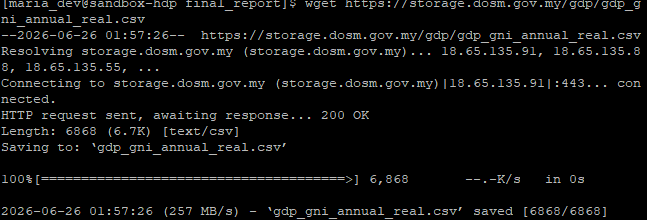

### 4.2 Create Hive Database

```sql
CREATE DATABASE IF NOT EXISTS economic_analytics;

USE economic_analytics;

SHOW DATABASES;
```

**Figure 4.2** Creating a new database in Hive
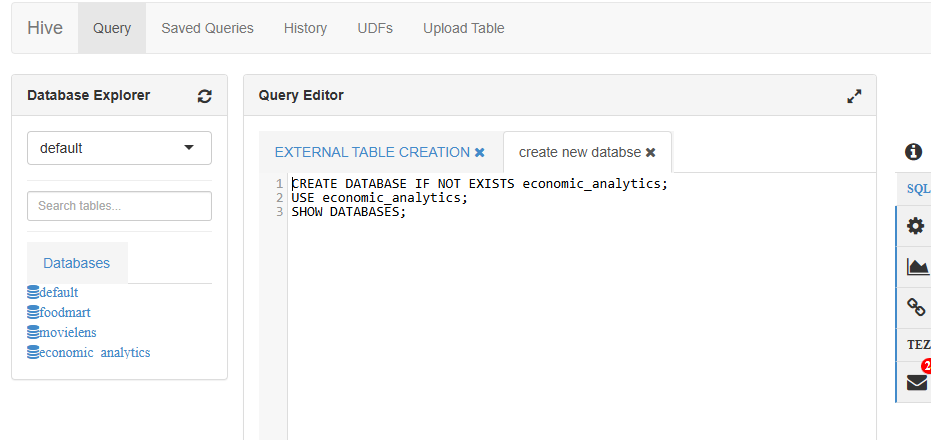

### 4.3 Create Hive External Table

```sql
CREATE DATABASE IF NOT EXISTS economic_analytics;

USE economic_analytics;

DROP TABLE IF EXISTS gdp_gni_annual_real;

CREATE EXTERNAL TABLE gdp_gni_annual_real (
    series STRING,
    year_date STRING,
    gdp DOUBLE,
    gni DOUBLE,
    gdp_capita DOUBLE,
    gni_capita DOUBLE
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
STORED AS TEXTFILE
LOCATION '/user/maria_dev/final_report'
TBLPROPERTIES ("skip.header.line.count"="1");
```

**Figure 4.3** Creating a new external table

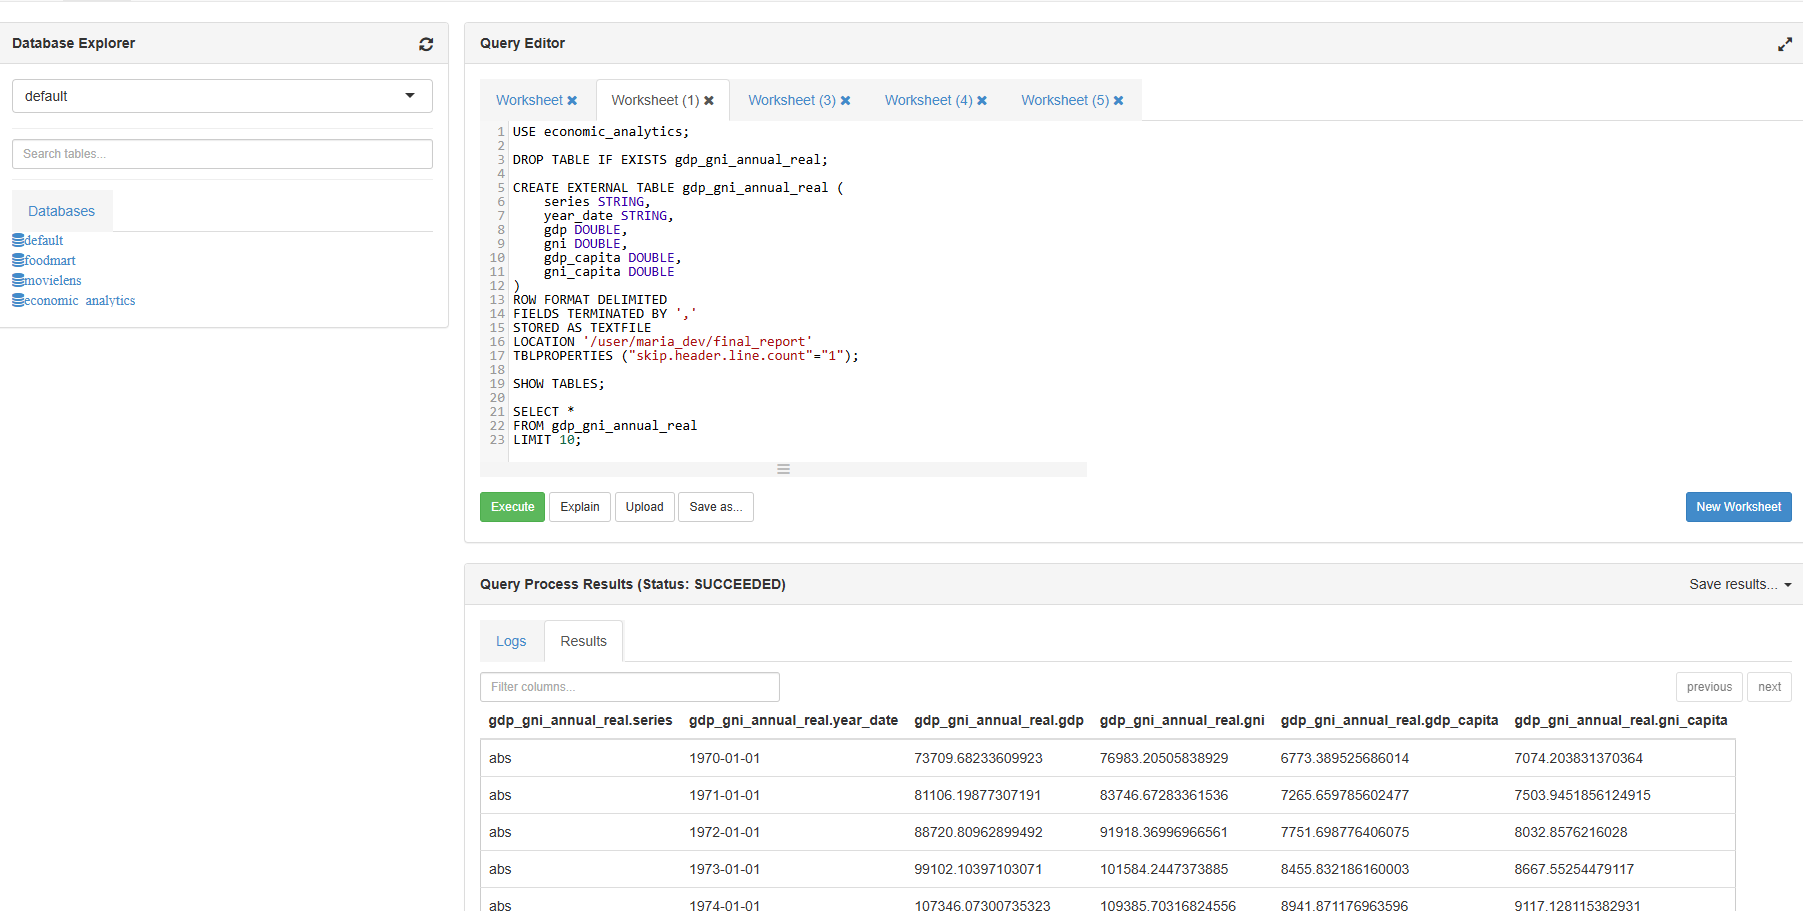

### 4.4 Query dataset using Hive SQL

```sql
-- Count total records
SELECT COUNT(*) AS total_records
FROM gdp_gni_annual_real;

-- Count records by series
SELECT series, COUNT(*) AS total_records
FROM gdp_gni_annual_real
GROUP BY series;

-- View the latest available years for absolute real GDP
SELECT year_date, gdp
FROM gdp_gni_annual_real
WHERE series = 'abs'
ORDER BY year_date DESC
LIMIT 10;

-- Top years by real GDP growth
SELECT year_date, gdp AS gdp_growth_rate, gni AS gni_growth_rate
FROM gdp_gni_annual_real
WHERE series = 'growth_yoy'
ORDER BY gdp DESC
LIMIT 10;

```

**Figure 4.4.1**  Count total records by series

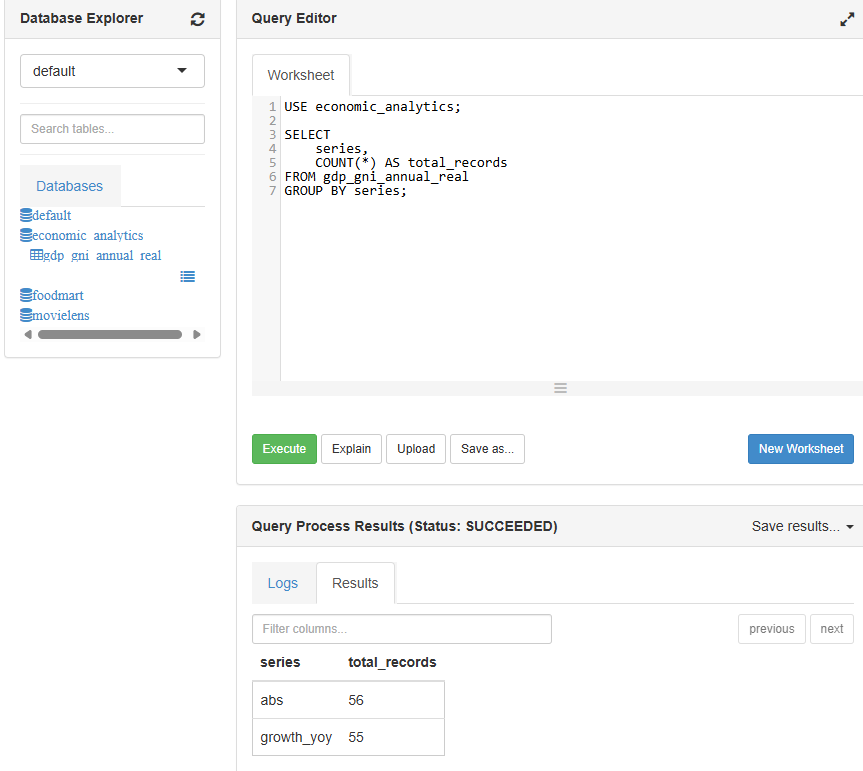

**Figure 4.4.2** Latest available years for abs real GDP

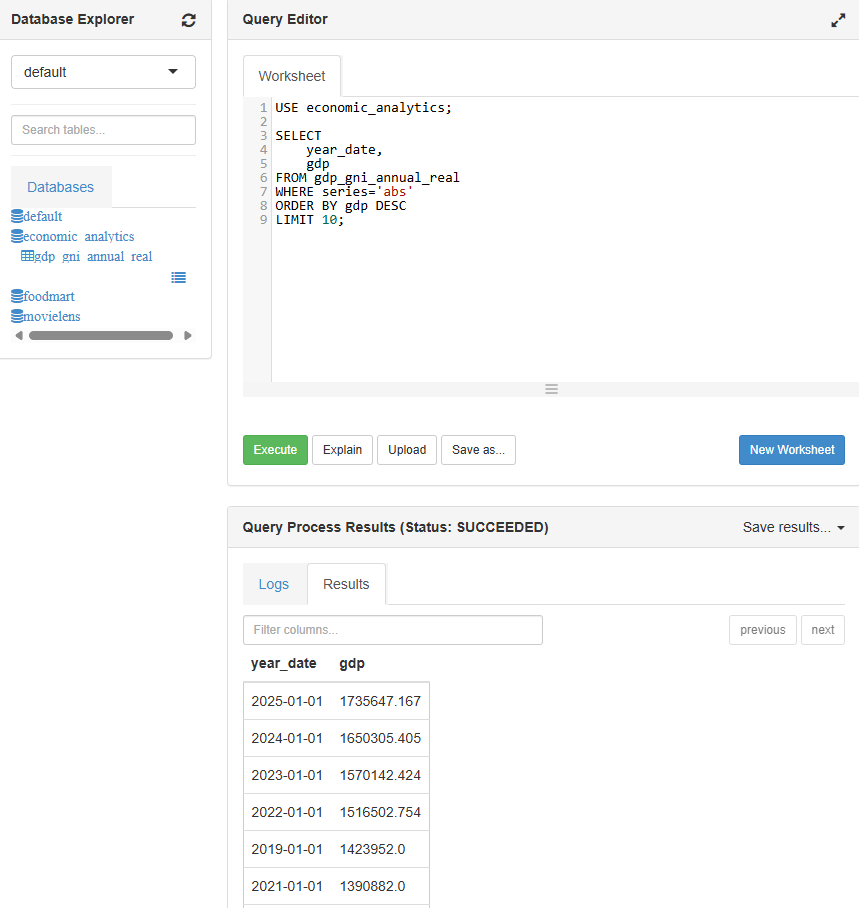

# 5.0 Data Cleaning and Preparation

After validating the dataset using Apache Hive, the data was prepared in Python for exploratory analysis. The date column was converted into datetime format, the year was extracted, and the dataset was separated into absolute values and year-over-year growth rates.

In [109]:
# Convert date column and extract year
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# Separate absolute values and year-over-year growth rates
df_abs = df[df['series'] == 'abs'].copy()
df_growth = df[df['series'] == 'growth_yoy'].copy()

In [110]:
print("Absolute series shape:", df_abs.shape)
print("Growth series shape:", df_growth.shape)

print("\nAbsolute Series")
display(df_abs.head())

print("\nGrowth Series")
display(df_growth.head())

Absolute series shape: (56, 7)
Growth series shape: (55, 7)

Absolute Series


,series,date,gdp,gni,gdp_capita,gni_capita,year
0,abs,1970-01-01,73709.682336,76983.205058,6773.389526,7074.203831,1970
1,abs,1971-01-01,81106.198773,83746.672834,7265.659786,7503.945186,1971
2,abs,1972-01-01,88720.809629,91918.369970,7751.698776,8032.857622,1972
3,abs,1973-01-01,99102.103971,101584.244737,8455.832186,8667.552545,1973
4,abs,1974-01-01,107346.073007,109385.703168,8941.871177,9117.128115,1974



Growth Series


,series,date,gdp,gni,gdp_capita,gni_capita,year
56,growth_yoy,1971-01-01,10.0,8.8,7.3,6.1,1971
57,growth_yoy,1972-01-01,9.4,9.8,6.7,7.0,1972
58,growth_yoy,1973-01-01,11.7,10.5,9.1,7.9,1973
59,growth_yoy,1974-01-01,8.3,7.7,5.7,5.2,1974
60,growth_yoy,1975-01-01,0.8,2.3,-1.6,-0.3,1975


### Interpretation

The dataset was successfully prepared for analysis by converting the `date` column into datetime format and extracting the corresponding year. The dataset was then separated into two subsets based on the `series` variable:

- **df_abs** contains the actual (absolute) values of GDP, GNI, GDP per capita and GNI per capita.
- **df_growth** contains the year-over-year growth rates of the same economic indicators.

Separating the dataset allows each series to be analysed independently, ensuring that absolute economic values and growth rates are interpreted appropriately.

## 5.1 Data Cleaning and Feature Engineering

The following preprocessing steps were performed to prepare the dataset for analysis. These include converting the date column into an appropriate format, extracting the observation year, separating the absolute and growth rate series, and creating additional variables to support further economic analysis.

- Converted the `date` column into datetime format.
- Extracted the `year` from the date column.
- Split the dataset into absolute values (`df_abs`) and year-over-year growth rates (`df_growth`).
- Created `gdp_gni_gap` to measure the difference between GDP and GNI.
- Created `gdp_gni_gap_percent` to express the GDP-GNI gap as a percentage of GDP.
- Created `decade` to support decade-level growth comparison.

In [111]:
# Create additional variables for analysis
df_abs['gdp_gni_gap'] = df_abs['gdp'] - df_abs['gni']
df_abs['gdp_gni_gap_percent'] = (df_abs['gdp_gni_gap'] / df_abs['gdp']) * 100

df_growth['decade'] = (df_growth['year'] // 10) * 10

df_abs[['year', 'gdp', 'gni', 'gdp_capita', 'gni_capita', 'gdp_gni_gap', 'gdp_gni_gap_percent']].head()

,year,gdp,gni,gdp_capita,gni_capita,gdp_gni_gap,gdp_gni_gap_percent
0,1970,73709.682336,76983.205058,6773.389526,7074.203831,-3273.522722,-4.441103
1,1971,81106.198773,83746.672834,7265.659786,7503.945186,-2640.474061,-3.255576
2,1972,88720.809629,91918.369970,7751.698776,8032.857622,-3197.560341,-3.604070
3,1973,99102.103971,101584.244737,8455.832186,8667.552545,-2482.140766,-2.504630
4,1974,107346.073007,109385.703168,8941.871177,9117.128115,-2039.630161,-1.900051


### Interpretation

The newly created variables support deeper economic analysis. The GDP-GNI gap helps identify differences between domestic production and national income, while the gap percentage standardises this difference relative to GDP. The decade variable allows long-term growth patterns to be compared across different economic periods.

## 5.2 Descriptive Statistics

Descriptive statistics are used to summarise the central tendency, range, and variability of GDP, GNI, GDP per capita, and GNI per capita before performing exploratory data analysis.

In [112]:
df_abs[['gdp',
        'gni',
        'gdp_capita',
        'gni_capita',
        'gdp_gni_gap',
        'gdp_gni_gap_percent']].describe().T

,count,mean,std,min,25%,50%,75%,max
gdp,56.0,631791.729647,489952.723165,73709.682336,206009.460501,517720.718477,969822.500315,1.735647e+06
gni,56.0,621950.642221,475023.298051,76983.205058,203072.195924,516360.144078,941960.368667,1.667109e+06
gdp_capita,56.0,24206.235966,12614.115608,6773.389526,13023.381393,23471.790671,33238.966938,5.070712e+04
gni_capita,56.0,23921.827334,12125.329252,7074.203831,12954.131611,23231.600584,32285.523754,4.870476e+04
gdp_gni_gap,56.0,9841.087426,17858.503861,-7591.527073,-3116.688336,3079.795530,18603.459089,6.853836e+04
gdp_gni_gap_percent,56.0,0.282033,2.190151,-4.441103,-1.412838,0.496547,1.808356,3.948865e+00


### Interpretation

The descriptive statistics provide an overview of Malaysia's economic indicators over the study period. Real GDP and GNI show substantial increases between the minimum and maximum values, reflecting long-term economic growth. GDP per capita and GNI per capita exhibit similar upward trends, indicating improvements in average income over time.

The GDP–GNI gap remains relatively small compared to the overall size of the economy, while the GDP–GNI gap percentage shows that the difference between domestic production and national income is generally modest throughout the study period. These summary statistics provide a useful baseline before exploring trends and relationships through visualisations.

# 6.0 Exploratory Data Analysis and Visualisation

This section explores the trends and relationships among Malaysia's economic indicators using various visualisations. The analysis focuses on real GDP, GNI, GDP per capita, GNI per capita, and annual growth rates to identify long-term economic patterns and provide meaningful business insights.

### 6.1 Trend of Real GDP and Real GNI

The following code visualises the long-term trend of Malaysia's Real GDP and Real GNI from 1970 to 2025. This comparison helps identify overall economic growth patterns and major disruptions over time. A line chart is used to examine the long-term trends of Malaysia's real Gross Domestic Product (GDP) and Gross National Income (GNI). Comparing these two indicators helps illustrate how domestic economic production and national income have evolved over time.

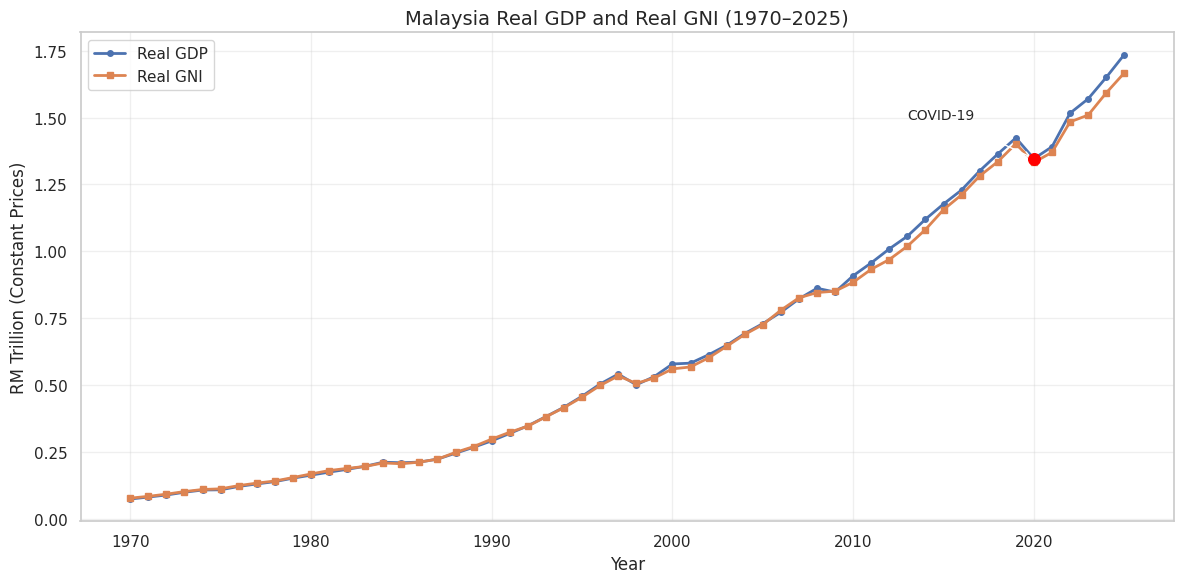

In [113]:
# Create a new figure
plt.figure(figsize=(12,6))

# Plot Real GDP in RM trillion
plt.plot(
    df_abs['year'],
    df_abs['gdp'] / 1_000_000,
    marker='o',
    linewidth=2,
    markersize=4,
    label='Real GDP'
)

# Plot Real GNI in RM trillion
plt.plot(
    df_abs['year'],
    df_abs['gni'] / 1_000_000,
    marker='s',
    linewidth=2,
    markersize=4,
    label='Real GNI'
)

# Highlight COVID-19 period
covid = df_abs[df_abs['year'] == 2020]

plt.scatter(
    covid['year'],
    covid['gdp'] / 1_000_000,
    color='red',
    s=70,
    zorder=5
)

plt.annotate(
    'COVID-19',
    xy=(2020, (covid['gdp'] / 1_000_000).values[0]),
    xytext=(2013, (covid['gdp'] / 1_000_000).values[0] + 0.15),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

# Add chart title and axis labels
plt.title('Malaysia Real GDP and Real GNI (1970–2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('RM Trillion (Constant Prices)', fontsize=12)

# Display legend and grid
plt.legend()
plt.grid(alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### Interpretation

Figure 6.1 shows the long-term trend of Malaysia's real Gross Domestic Product (GDP) and Gross National Income (GNI) from 1970 to 2025. Both indicators display a consistent upward trend, reflecting sustained economic growth over the study period. Real GDP remains slightly higher than real GNI throughout the period, indicating that the value of goods and services produced within Malaysia exceeds the income received by Malaysian residents from abroad.

A noticeable decline occurred in 2020 due to the COVID-19 pandemic, which disrupted economic activities nationwide. However, both GDP and GNI recovered in the following years and continued their long-term upward trend, demonstrating Malaysia's economic resilience.

### 6.2 Trend of Real GDP per Capita and Real GNI per Capita

The following visualisation compares Real GDP per Capita and Real GNI per Capita over time to evaluate changes in economic output and national income on a per-person basis. Visualising these indicators over time helps assess improvements in Malaysia's standard of living and overall economic well-being.



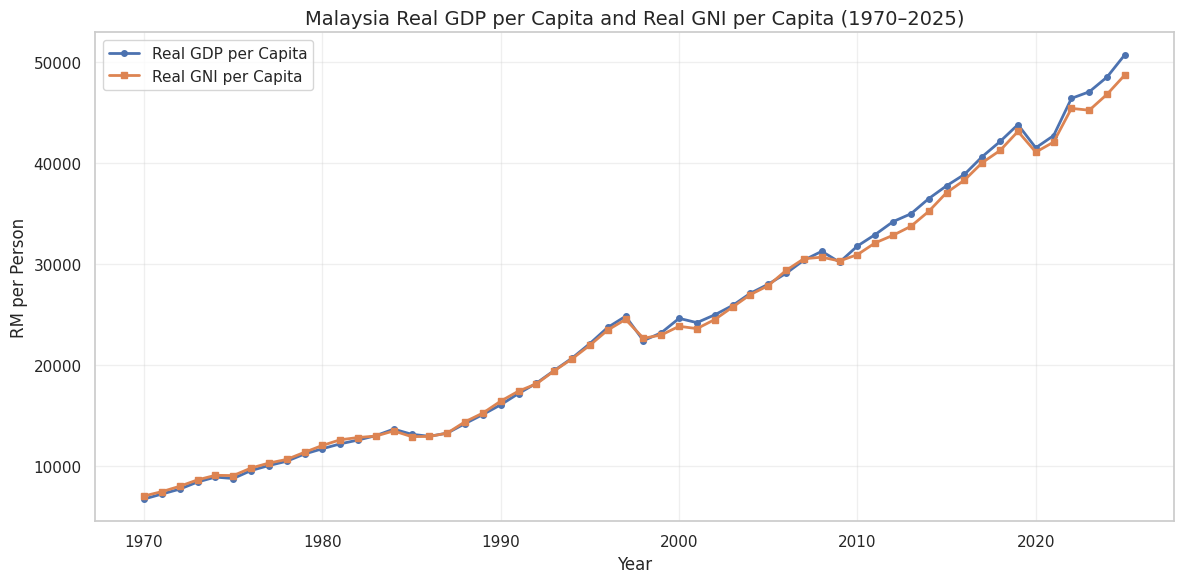

In [114]:
# Create a new figure
plt.figure(figsize=(12,6))

# Plot Real GDP per capita
plt.plot(df_abs['year'], df_abs['gdp_capita'],
         marker='o', linewidth=2, markersize=4,
         label='Real GDP per Capita')

# Plot Real GNI per capita
plt.plot(df_abs['year'], df_abs['gni_capita'],
         marker='s', linewidth=2, markersize=4,
         label='Real GNI per Capita')

# Add chart title and axis labels
plt.title('Malaysia Real GDP per Capita and Real GNI per Capita (1970–2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('RM per Person', fontsize=12)

# Display legend and grid
plt.legend()
plt.grid(alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### Interpretation

Figure 6.2 shows the trend of Malaysia's real GDP per capita and real GNI per capita from 1970 to 2025. Both indicators increased steadily over time, suggesting improvement in average economic output and income per person.

The two lines move closely together, indicating that income growth generally followed the expansion of economic output. A temporary decline can be observed around 2020 due to the COVID-19 pandemic, but both indicators recovered in the following years.

### 6.3 Annual GDP and Real GNI Growth Rate

Annual growth rates provide insight into Malaysia's economic performance by showing how GDP and GNI change from one year to the next. This visualization highlights periods of economic expansion and contraction, allowing major economic events and recovery periods to be identified.

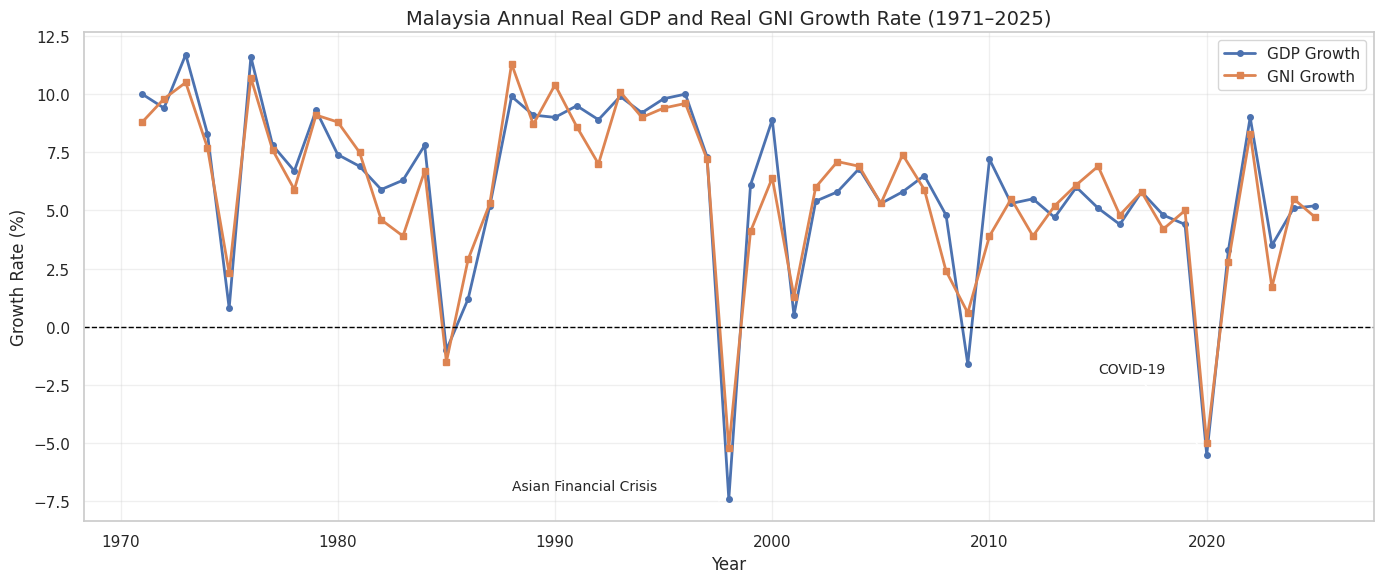

In [115]:
# Create a new figure
plt.figure(figsize=(14,6))

# Plot annual GDP growth rate
plt.plot(
    df_growth['year'],
    df_growth['gdp'],
    marker='o',
    linewidth=2,
    markersize=4,
    label='GDP Growth'
)

# Plot annual GNI growth rate
plt.plot(
    df_growth['year'],
    df_growth['gni'],
    marker='s',
    linewidth=2,
    markersize=4,
    label='GNI Growth'
)

# Asian Financial Crisis (1998)
plt.annotate(
    'Asian Financial Crisis',
    xy=(1998, df_growth[df_growth['year']==1998]['gdp'].values[0]),
    xytext=(1988, -7),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

# COVID-19 Pandemic (2020)
plt.annotate(
    'COVID-19',
    xy=(2020, df_growth[df_growth['year']==2020]['gdp'].values[0]),
    xytext=(2015, -2),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)


# Add zero-growth reference line
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Add chart title and axis labels
plt.title('Malaysia Annual Real GDP and Real GNI Growth Rate (1971–2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)

# Display legend and grid
plt.legend()
plt.grid(alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### Interpretation

Figure 6.3 illustrates the annual growth rates of Malaysia's real GDP and real GNI. Unlike the steadily increasing GDP values shown previously, the growth rates fluctuate over time due to changes in economic conditions.

The largest contraction occurred during the Asian Financial Crisis in 1998, while another significant decline was observed in 2020 due to the COVID-19 pandemic. Following both events, Malaysia's economy recovered, with GDP and GNI growth returning to positive levels. Overall, GDP and GNI growth rates follow similar patterns, indicating the close relationship between domestic production and national income.

### 6.4 Average GDP and GNI Growth by Economic Period

Annual growth rates fluctuate from year to year due to economic cycles and external shocks. To provide a clearer comparison, the years are grouped into major economic periods that reflect important phases in Malaysia's economic development. This allows the average GDP and GNI growth rates to be compared across different economic conditions.

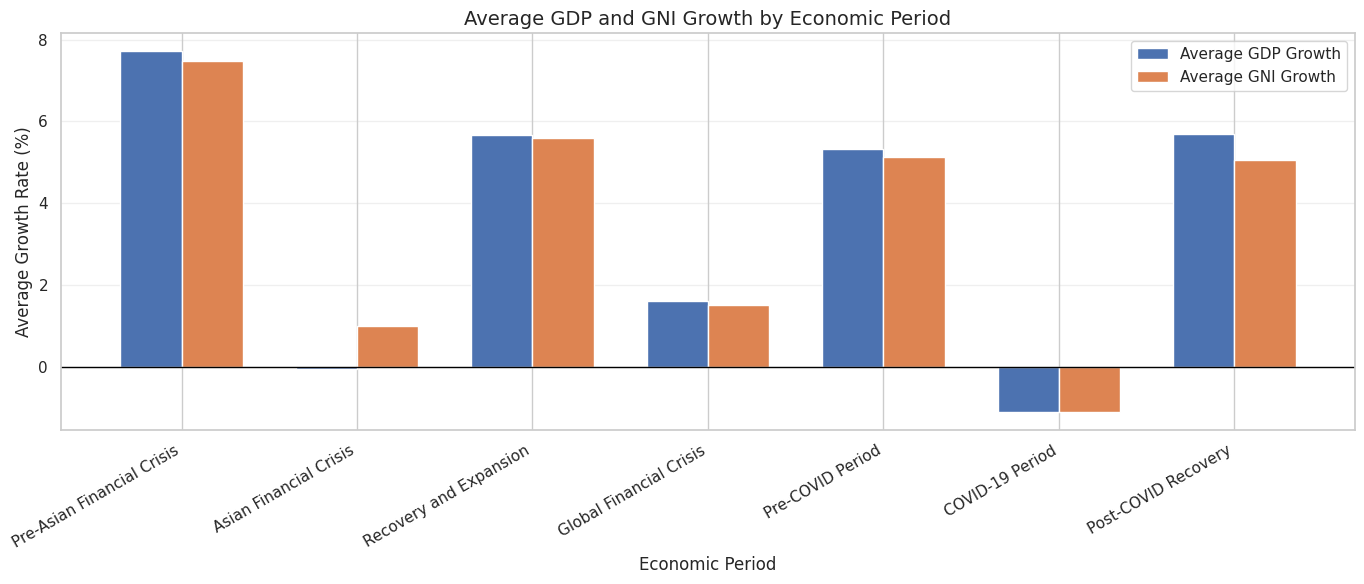

,economic_period,gdp,gni
4,Pre-Asian Financial Crisis,7.715385,7.488462
0,Asian Financial Crisis,-0.050000,1.000000
6,Recovery and Expansion,5.677778,5.600000
2,Global Financial Crisis,1.600000,1.500000
5,Pre-COVID Period,5.320000,5.130000
1,COVID-19 Period,-1.100000,-1.100000
3,Post-COVID Recovery,5.700000,5.050000


In [116]:
# Categorise each year into a major economic period
def classify_period(year):
    if year <= 1996:
        return 'Pre-Asian Financial Crisis'
    elif year <= 1998:
        return 'Asian Financial Crisis'
    elif year <= 2007:
        return 'Recovery and Expansion'
    elif year <= 2009:
        return 'Global Financial Crisis'
    elif year <= 2019:
        return 'Pre-COVID Period'
    elif year <= 2021:
        return 'COVID-19 Period'
    else:
        return 'Post-COVID Recovery'

df_growth['economic_period'] = df_growth['year'].apply(classify_period)

# Calculate average GDP and GNI growth by economic period
period_growth = df_growth.groupby('economic_period')[['gdp', 'gni']].mean().reset_index()

period_order = [
    'Pre-Asian Financial Crisis',
    'Asian Financial Crisis',
    'Recovery and Expansion',
    'Global Financial Crisis',
    'Pre-COVID Period',
    'COVID-19 Period',
    'Post-COVID Recovery'
]

period_growth['economic_period'] = pd.Categorical(
    period_growth['economic_period'],
    categories=period_order,
    ordered=True
)

period_growth = period_growth.sort_values('economic_period')

# Create grouped bar chart
plt.figure(figsize=(14,6))

x = np.arange(len(period_growth))
width = 0.35

# Plot average GDP growth
plt.bar(x - width/2, period_growth['gdp'], width, label='Average GDP Growth')

# Plot average GNI growth
plt.bar(x + width/2, period_growth['gni'], width, label='Average GNI Growth')

# Add chart title and axis labels
plt.xticks(x, period_growth['economic_period'], rotation=30, ha='right')
plt.title('Average GDP and GNI Growth by Economic Period', fontsize=14)
plt.xlabel('Economic Period', fontsize=12)
plt.ylabel('Average Growth Rate (%)', fontsize=12)

plt.axhline(0, color='black', linewidth=1)

# Display legend and grid
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Adjust layout and display chart
plt.tight_layout()
plt.show()

period_growth

### Interpretation

Figure 6.4 compares the average annual growth rates of Malaysia's real GDP and real GNI across major economic periods. The Pre-Asian Financial Crisis period recorded the highest average growth, with both GDP and GNI growing at approximately 7–8% per year. This reflects Malaysia's strong economic expansion before the 1997–1998 crisis.

During the Asian Financial Crisis period, average growth declined sharply. Although 1998 recorded a severe contraction, the positive growth in 1997 offset part of the decline, resulting in average GDP growth close to 0% and average GNI growth of approximately 1%.

The Recovery and Expansion period and the Pre-COVID period show more stable growth, with average GDP and GNI growth around 5–6%. The Global Financial Crisis period still recorded positive but much lower average growth, indicating a slowdown rather than a full contraction.

The COVID-19 period recorded the only negative average growth among all periods, showing the strong impact of the pandemic on Malaysia's economy. However, the Post-COVID Recovery period shows that both GDP and GNI returned to positive growth, indicating economic recovery after the pandemic.

Overall, GDP and GNI show similar growth patterns across all periods, suggesting a close relationship between Malaysia's domestic production and national income. It should also be noted that the economic periods have different lengths, so the values represent average annual growth rates rather than cumulative growth.

### 6.5 GDP–GNI Gap Analysis

#### 6.5.1 GDP–GNI Gap (RM Million)
Besides analysing GDP and GNI individually, it is also useful to examine the difference between these two indicators. The GDP–GNI gap measures the difference between domestic economic production and the income received by Malaysian residents. Analysing this gap provides additional insight into Malaysia's economic structure over time.

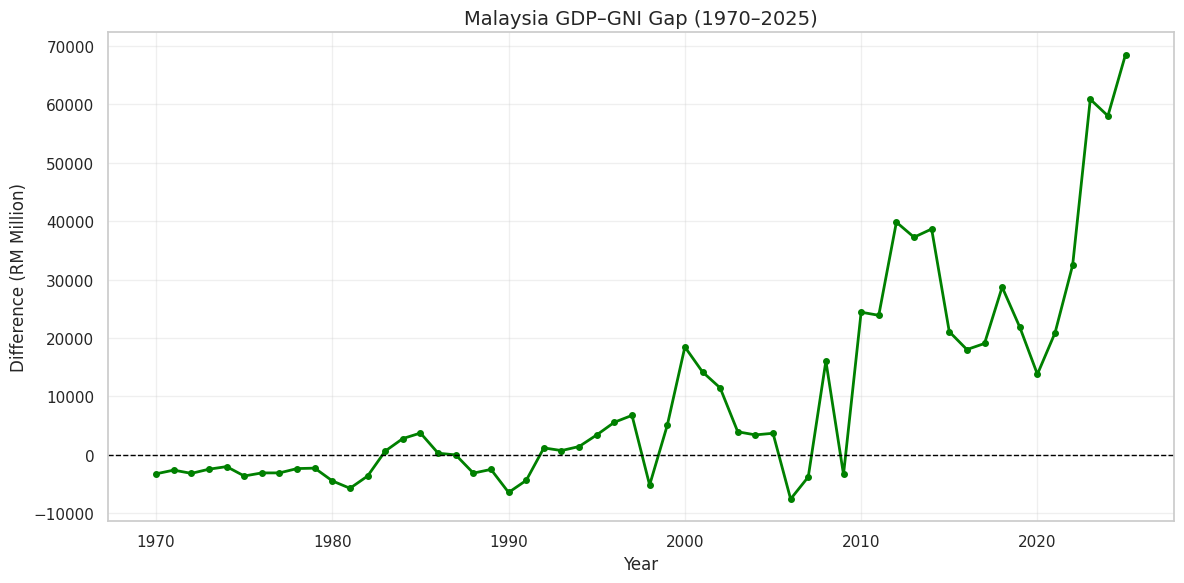

In [117]:
# Create a line chart for the GDP-GNI gap
plt.figure(figsize=(12,6))

# Plot GDP-GNI gap over time
plt.plot(
    df_abs['year'],
    df_abs['gdp_gni_gap'],
    marker='o',
    linewidth=2,
    markersize=4,
    color='green'
)

# Add chart title and axis labels
plt.title('Malaysia GDP–GNI Gap (1970–2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Difference (RM Million)', fontsize=12)

# Add zero reference line
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Display grid
plt.grid(alpha=0.3)
plt.tight_layout()

# Show chart
plt.show()

### Interpretation

Figure 6.5 illustrates the difference between Malaysia's real GDP and real GNI from 1970 to 2025. During the early years (1970–1997), the GDP–GNI gap remained relatively small and fluctuated around zero, with several years recording negative values, indicating that GNI occasionally exceeded GDP.

From the late 1990s onwards, the gap became more volatile, with noticeable fluctuations during periods of economic uncertainty. Beginning around 2010, the GDP–GNI gap became consistently positive and generally widened over time. The largest gap was observed between 2023 and 2025, indicating that Malaysia's real GDP grew at a faster pace than its real GNI during the later years of the study period.

Overall, the findings suggest that although GDP and GNI continue to move in the same direction, the difference between domestic economic production and national income has become more pronounced in recent years.

#### 6.5.2 GDP–GNI Gap (% of GDP)

While the GDP–GNI gap shows the absolute difference between the two indicators, expressing the gap as a percentage of GDP provides a standardised measure. This allows the difference to be compared consistently across years regardless of changes in the overall size of the economy.

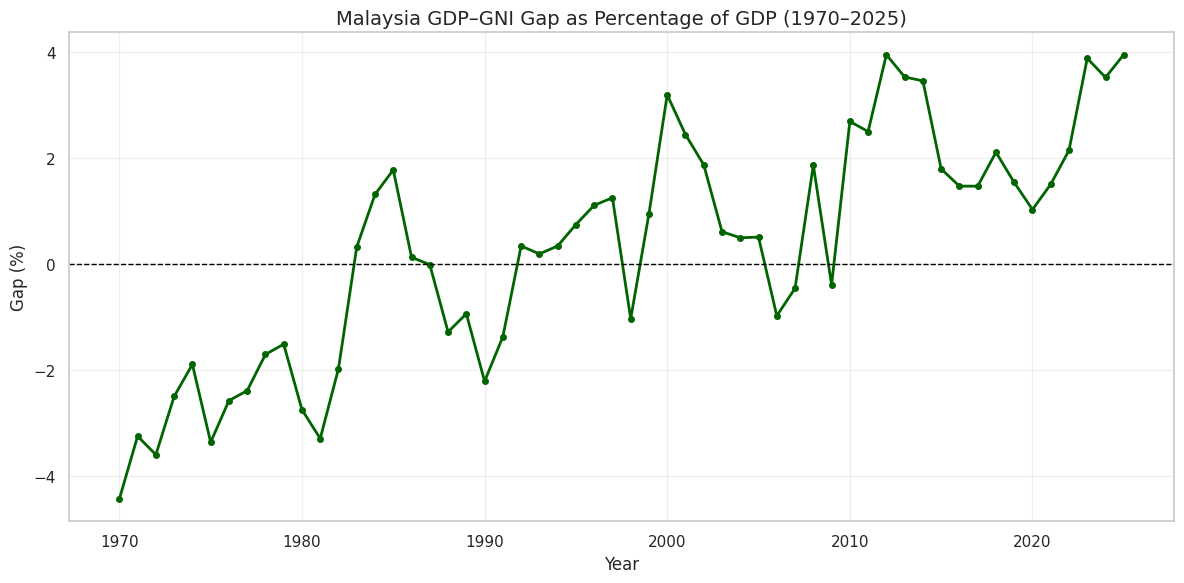

In [118]:
# Create a line chart for GDP-GNI gap percentage
plt.figure(figsize=(12,6))

# Plot GDP-GNI gap as a percentage of GDP
plt.plot(
    df_abs['year'],
    df_abs['gdp_gni_gap_percent'],
    marker='o',
    linewidth=2,
    markersize=4,
    color='darkgreen'
)

# Add zero reference line
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Add chart title and axis labels
plt.title('Malaysia GDP–GNI Gap as Percentage of GDP (1970–2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Gap (%)', fontsize=12)

# Display grid
plt.grid(alpha=0.3)
plt.tight_layout()

# Show chart
plt.show()

### Interpretation

Figure 6.5.2 presents the GDP–GNI gap as a percentage of GDP from 1970 to 2025. During the early years of the study period, the percentage gap was generally negative, indicating that real GNI was occasionally higher than real GDP. The percentage fluctuated around zero until the late 1990s, reflecting relatively small differences between the two economic indicators.

From around 2000 onwards, the GDP–GNI gap percentage became predominantly positive and showed an overall increasing trend, despite several short-term fluctuations. The highest values, approaching 4%, were recorded during the 2010s and again in the post-COVID recovery period (2023–2025). This indicates that the gap between Malaysia's domestic economic production and national income became proportionally larger in recent years.

Overall, the results suggest that although real GDP and real GNI continue to move closely together, real GDP has grown at a slightly faster pace than real GNI in the later years of the study period, resulting in a gradually widening proportional gap.

### 6.6 Correlation Analysis

Correlation analysis was performed to examine the strength and direction of the relationships among the selected economic indicators. The correlation matrix provides a concise summary of how closely these variables move together over time.

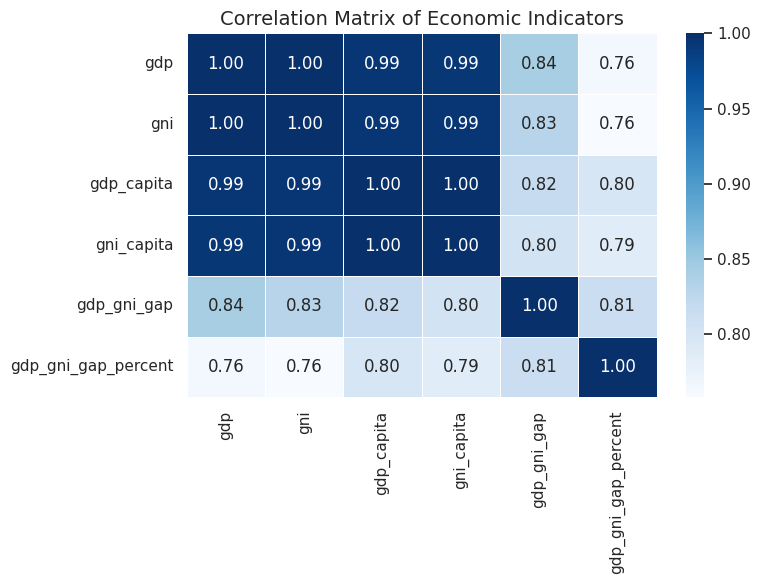

In [119]:
import seaborn as sns

# Compute the correlation matrix
corr = df_abs[['gdp',
               'gni',
               'gdp_capita',
               'gni_capita',
               'gdp_gni_gap',
               'gdp_gni_gap_percent']].corr()

# Create heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

# Add chart title
plt.title('Correlation Matrix of Economic Indicators', fontsize=14)

plt.tight_layout()
plt.show()

### Interpretation

Figure 6.6 presents the correlation matrix of the selected economic indicators. The results show that all variables are positively correlated, indicating that they generally increase together over time.

Real GDP and real GNI exhibit an almost perfect positive correlation (1.00), suggesting that increases in Malaysia's economic output are closely accompanied by increases in national income. Similarly, GDP per capita and GNI per capita are also almost perfectly correlated (1.00), reflecting the strong relationship between overall economic growth and average income per person.

The GDP–GNI gap and GDP–GNI gap percentage show moderate to strong positive correlations with the other economic indicators, with correlation coefficients ranging from 0.76 to 0.84. This indicates that although the gap tends to increase as the economy grows, it does not expand at exactly the same rate as GDP or GNI.

Overall, the correlation analysis demonstrates that Malaysia's key economic indicators are highly interconnected, with GDP and GNI showing the strongest relationship throughout the study period.

### 6.7 Relationship Between Real GDP and Real GNI

A scatter plot is used to examine the relationship between Malaysia's real GDP and real GNI. This visualization helps determine whether changes in domestic economic production are closely associated with changes in national income.

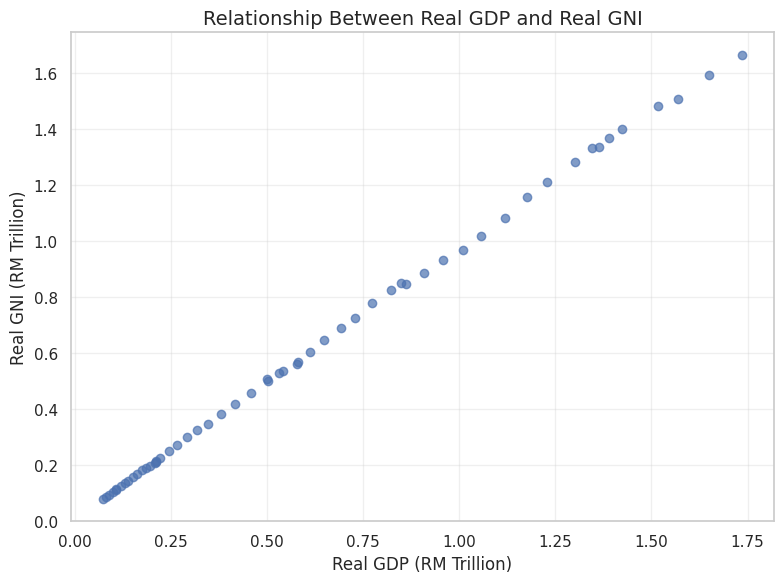

In [120]:
# Create scatter plot to examine the relationship between GDP and GNI
plt.figure(figsize=(8,6))

# Plot the relationship between Real GDP and Real GNI in RM trillion
plt.scatter(
    df_abs['gdp'] / 1_000_000,
    df_abs['gni'] / 1_000_000,
    alpha=0.7
)

# Add chart title and axis labels
plt.title('Relationship Between Real GDP and Real GNI', fontsize=14)
plt.xlabel('Real GDP (RM Trillion)', fontsize=12)
plt.ylabel('Real GNI (RM Trillion)', fontsize=12)

# Display grid
plt.grid(alpha=0.3)

# Show chart
plt.tight_layout()
plt.show()

### Interpretation

Figure 6.7 illustrates the relationship between Malaysia's real GDP and real GNI. The data points form a clear upward linear pattern, indicating a very strong positive relationship between the two variables. As real GDP increases, real GNI also increases proportionally.

The absence of noticeable outliers suggests that the relationship remains consistent throughout the study period despite fluctuations caused by economic crises. This finding is consistent with the correlation analysis, which reported an almost perfect positive correlation between GDP and GNI.

Overall, the scatter plot confirms that Malaysia's economic output and national income have moved closely together over time, reflecting the strong linkage between domestic production and income generation.

# 7.0 Key Insights and Discussion

Based on the exploratory data analysis, several important insights were identified regarding Malaysia's economic performance from 1970 to 2025.

First, both real GDP and real GNI demonstrated a strong long-term upward trend, indicating sustained economic growth over the study period. Although temporary declines occurred during major economic crises, the overall direction remained positive.

Second, real GDP per capita and real GNI per capita also increased substantially over time, suggesting continuous improvements in average economic output and income per person.

Third, the annual growth rate analysis revealed that Malaysia's economy has experienced several periods of economic slowdown, particularly during the Asian Financial Crisis (1997–1998) and the COVID-19 pandemic (2020–2021). Despite these challenges, the economy showed resilience by returning to positive growth in the post-COVID period.

Fourth, the GDP–GNI gap analysis indicated that the difference between domestic production and national income has become more pronounced in recent years. Both the absolute gap and the percentage gap increased after 2000, suggesting that real GDP has grown slightly faster than real GNI.

Finally, the correlation analysis confirmed that Malaysia's major economic indicators are highly interconnected. Real GDP and real GNI exhibited an almost perfect positive correlation, while the scatter plot further demonstrated a strong linear relationship between these variables.

Overall, the analysis provides a comprehensive overview of Malaysia's long-term economic development and highlights the usefulness of integrating Apache Hive for data management with Python for statistical analysis and data visualization.

# 8.0 Recommendations

Based on the findings of this study, the following recommendations are proposed:

1. Government agencies and economic analysts should monitor both GDP and GNI simultaneously when evaluating Malaysia's economic performance, as each indicator provides different perspectives on economic development.

2. Historical economic crises, such as the Asian Financial Crisis and the COVID-19 pandemic, should continue to be considered when formulating economic policies and forecasting future economic performance.

3. Future studies should extend the analysis by incorporating quarterly GDP and GNI data to provide more detailed insights into short-term economic fluctuations.

4. Additional macroeconomic indicators such as inflation rate, unemployment rate, exchange rate, and foreign direct investment (FDI) could be integrated to provide a more comprehensive assessment of Malaysia's economy.

5. More advanced analytical techniques, including time series forecasting and machine learning models, may be applied in future work to predict Malaysia's future economic performance and support evidence-based decision-making.

## 8.1 Limitations

Although this study provides useful insights into Malaysia's economic performance, several limitations should be acknowledged. First, the analysis is based on annual aggregated data, which may not capture short-term economic fluctuations. Second, only GDP and GNI indicators were analysed, other macroeconomic variables such as inflation, unemployment, and foreign direct investment could provide additional perspectives. Finally, this project focuses on exploratory data analysis rather than predictive modelling.

# 9.0 Conclusion

This project successfully analysed Malaysia's Annual Real GDP and GNI data from 1970 to 2025 using Apache Hive and Python. Apache Hive simplified the management and querying of structured economic data stored in HDFS, while Python provided flexible tools for data cleaning, feature engineering, visualization, and analysis.

The analysis showed that Malaysia has experienced significant long-term economic growth, although temporary declines occurred during major economic crises. Real GDP and real GNI exhibited very similar trends throughout the study period, supported by an almost perfect positive correlation. The GDP–GNI gap analysis further revealed that the difference between domestic production and national income has widened in recent years, although both indicators continue to move closely together.

Overall, this project successfully demonstrated the integration of Apache Hive and Python in a complete big data analytics workflow, from data management in HDFS to exploratory analysis and visualisation. The findings provide meaningful insights into Malaysia's long-term economic performance while illustrating the practical application of big data technologies in analysing structured economic datasets.